# 📊 PROYECTO · ANALISTA IA DE VENTAS MENSUALES

Construiremos un asistente de análisis de ventas aplicado a un CSV mensual.

| Paso | Concepto | Función |
|---|---|---|
| ① | **Fine-Tuning + LoRA** | Clasifica la consulta en **ANALISIS / RESUMEN / CONCEPTO / FUERA_ALCANCE** |
| ② | **Pandas** | Calcula respuestas exactas directamente sobre el CSV |
| ③ | **Embeddings + RAG** | Recupera definiciones y conocimiento textual |
| ④ | **Prompt Engineering + Groq** | Interpreta consultas y redacta respuestas |
| ⑤ | **Evaluación** | Mide clasificador, RAG y fidelidad de las respuestas |
| ⑥ | **Gradio** | Integra todo en una demo |

> **Idea clave:** Fine-Tuning decide la ruta; Pandas hace los cálculos; RAG recupera conocimiento textual; Groq interpreta y redacta.

### Plan
`Instalar → Groq → CSV → Validar → Analizar → RAG → Dataset → Antes → LoRA → Después → Motor Pandas → Pipeline → Juez → Gradio`

## Paso 1 · Instalar herramientas
Instalamos Hugging Face, PEFT/LoRA, Sentence Transformers, Groq y Gradio.

In [33]:
%%capture
!pip uninstall -y torchao
!pip install -q transformers peft datasets accelerate sentence-transformers groq "gradio>=6,<7" scikit-learn

## Paso 2 · Conectar Groq desde Colab Secrets
Guarda tu API key en **Colab Secrets** con el nombre `GROQ_API_KEY`.

In [34]:
import json, time
from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("No se encontró GROQ_API_KEY en Colab Secrets.")

client = Groq(api_key=GROQ_API_KEY)
MODELO_GROQ = "openai/gpt-oss-20b"

def preguntar_groq(prompt, temperatura=0.0):
    for intento in (1, 2):
        try:
            r = client.chat.completions.create(
                model=MODELO_GROQ,
                messages=[{"role":"user","content":prompt}],
                temperature=temperatura,
            )
            return r.choices[0].message.content.strip()
        except Exception as e:
            if intento == 1:
                print("⏳ Reintentando en 5 segundos...")
                time.sleep(5)
            else:
                raise e

print("Groq listo ·", MODELO_GROQ)

Groq listo · openai/gpt-oss-20b


## Paso 3 · Cargar el CSV
El notebook trabaja con columnas en español, pero también renombra automáticamente los encabezados originales en inglés.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# =========================================================
# 1. CARGAR ARCHIVO CSV
# =========================================================

archivos = files.upload()

ARCHIVO_CSV = next(iter(archivos.keys()))

df = pd.read_csv(ARCHIVO_CSV)


# =========================================================
# 2. NORMALIZAR NOMBRES DE COLUMNAS
# =========================================================

# Permite trabajar tanto con la versión original
# en inglés como con la versión renombrada en español.

alias_columnas = {
    "order_id": "id_orden",
    "date": "fecha",
    "customer_id": "id_cliente",
    "product": "producto",
    "category": "categoria",
    "brand": "marca",
    "region": "region",
    "channel": "canal",
    "payment_method": "metodo_pago",
    "units": "unidades",
    "unit_price": "precio_unitario",
    "discount_pct": "descuento_pct",
    "revenue": "venta",
}

df = df.rename(columns=alias_columnas)


# =========================================================
# 3. VALIDAR COLUMNAS NECESARIAS
# =========================================================

columnas_esperadas = [
    "id_orden",
    "fecha",
    "id_cliente",
    "producto",
    "categoria",
    "marca",
    "region",
    "canal",
    "metodo_pago",
    "unidades",
    "precio_unitario",
    "descuento_pct",
    "venta"
]

faltantes = [
    columna
    for columna in columnas_esperadas
    if columna not in df.columns
]

if faltantes:
    raise ValueError(
        f"Faltan columnas necesarias en el CSV: {faltantes}"
    )


# =========================================================
# 4. CONVERTIR LA COLUMNA FECHA
# =========================================================

# Guardamos temporalmente los valores originales como texto.
fecha_original = df["fecha"].astype(str).str.strip()

# Primero intentamos interpretar el formato:
# AAAA-MM-DD
fecha_iso = pd.to_datetime(
    fecha_original,
    format="%Y-%m-%d",
    errors="coerce"
)

# Si alguna fecha no fue reconocida, intentamos:
# DD/MM/AAAA
fecha_latina = pd.to_datetime(
    fecha_original,
    dayfirst=True,
    errors="coerce"
)

# Se utiliza primero el formato ISO y, cuando no funciona,
# se toma el formato latino.
df["fecha"] = fecha_iso.fillna(fecha_latina)


# =========================================================
# 5. VALIDAR CONVERSIÓN DE FECHAS
# =========================================================

fechas_invalidas = df["fecha"].isna().sum()

if fechas_invalidas > 0:
    print(
        f"⚠️ Se encontraron {fechas_invalidas} fechas "
        "que no pudieron convertirse."
    )
else:
    print("Fechas convertidas correctamente ✅")


# =========================================================
# 6. INFORMACIÓN GENERAL DEL ARCHIVO
# =========================================================

print("\nArchivo cargado ✅")
print("Archivo:", ARCHIVO_CSV)
print("Registros:", f"{len(df):,}")
print("Columnas:", len(df.columns))

print("\nPeriodo detectado:")
print("Fecha inicial:", df["fecha"].min().date())
print("Fecha final:", df["fecha"].max().date())

print("\nPrimeras fechas:")
display(df[["fecha"]].head(10))

print("\nPrimeros registros:")
display(df.head())

Saving ventas_marzo_2026.csv to ventas_marzo_2026 (4).csv
Fechas convertidas correctamente ✅

Archivo cargado ✅
Archivo: ventas_marzo_2026 (4).csv
Registros: 3,000
Columnas: 13

Periodo detectado:
Fecha inicial: 2026-03-01
Fecha final: 2026-03-31

Primeras fechas:


,fecha
0,2026-03-01
1,2026-03-01
2,2026-03-01
3,2026-03-01
4,2026-03-01
5,2026-03-01
6,2026-03-01
7,2026-03-01
8,2026-03-01
9,2026-03-01



Primeros registros:


,id_orden,fecha,id_cliente,producto,categoria,marca,region,canal,metodo_pago,unidades,precio_unitario,descuento_pct,venta
0,ORD-00001,2026-03-01,C-0559,Bicicleta Urban 21,Deportes,Move,Sur,Web,Tarjeta crédito,2,7499,0,"14,998.00"
1,ORD-00023,2026-03-01,C-0235,Smartphone X1,Electrónica,Nova,Occidente,Web,Tarjeta crédito,1,8999,0,"8,999.00"
2,ORD-00039,2026-03-01,C-0271,Bicicleta Urban 21,Deportes,Move,Occidente,App,Transferencia,2,7499,0,"14,998.00"
3,ORD-00042,2026-03-01,C-0723,Cafetera HomeBrew,Hogar,HomePlus,Norte,Web,Transferencia,1,1799,0,"1,799.00"
4,ORD-00043,2026-03-01,C-0379,Freidora AirCook,Hogar,KitchenLab,Centro,Marketplace,Tarjeta débito,1,2499,0,"2,499.00"


In [36]:
prueba_9_marzo = df[
    df["fecha"] == pd.Timestamp("2026-03-09")
]

print("Registros del 9 de marzo:", len(prueba_9_marzo))
print(
    "Ventas del 9 de marzo:",
    f"${prueba_9_marzo['venta'].sum():,.2f}"
)

Registros del 9 de marzo: 93
Ventas del 9 de marzo: $320,263.65


## Paso 4 · Validar la base
Revisamos estructura, nulos, duplicados y periodo.

In [37]:
print("=== ESTRUCTURA ===")
df.info()
print("\n=== NULOS ===")
display(df.isna().sum().to_frame("nulos"))
print("\n=== DUPLICADOS ===")
print("Filas duplicadas:", df.duplicated().sum())
print("ID de orden duplicados:", df["id_orden"].duplicated().sum())
print("\n=== PERIODO ===")
print("Fecha inicial:", df["fecha"].min().date())
print("Fecha final:", df["fecha"].max().date())
periodos = df["fecha"].dt.to_period("M").dropna().unique()

=== ESTRUCTURA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_orden         3000 non-null   object        
 1   fecha            3000 non-null   datetime64[ns]
 2   id_cliente       3000 non-null   object        
 3   producto         3000 non-null   object        
 4   categoria        3000 non-null   object        
 5   marca            3000 non-null   object        
 6   region           3000 non-null   object        
 7   canal            3000 non-null   object        
 8   metodo_pago      3000 non-null   object        
 9   unidades         3000 non-null   int64         
 10  precio_unitario  3000 non-null   int64         
 11  descuento_pct    3000 non-null   int64         
 12  venta            3000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(8)
memory usage: 304.8+

,nulos
id_orden,0
fecha,0
id_cliente,0
producto,0
categoria,0
marca,0
region,0
canal,0
metodo_pago,0
unidades,0



=== DUPLICADOS ===
Filas duplicadas: 0
ID de orden duplicados: 0

=== PERIODO ===
Fecha inicial: 2026-03-01
Fecha final: 2026-03-31


## Paso 5 · Análisis base del mes
Pandas será la fuente exacta de cálculo.

In [38]:
def resumen_mes(base):
    ventas_totales = float(base["venta"].sum())
    unidades_totales = int(base["unidades"].sum())
    ordenes_totales = int(base["id_orden"].nunique())
    clientes_unicos = int(base["id_cliente"].nunique())
    ticket_promedio = ventas_totales / ordenes_totales if ordenes_totales else 0
    return {
        "ventas_totales": round(ventas_totales,2),
        "unidades_totales": unidades_totales,
        "ordenes_totales": ordenes_totales,
        "clientes_unicos": clientes_unicos,
        "ticket_promedio": round(ticket_promedio,2),
    }

kpis = resumen_mes(df)
for k,v in kpis.items(): print(k,":",v)

ventas_totales : 12075836.0
unidades_totales : 4054
ordenes_totales : 3000
clientes_unicos : 908
ticket_promedio : 4025.28


In [39]:
ventas_categoria = (df.groupby("categoria",as_index=False)
    .agg(ventas=("venta","sum"),unidades=("unidades","sum"),ordenes=("id_orden","nunique"))
    .sort_values("ventas",ascending=False).reset_index(drop=True))

ventas_producto = (df.groupby(["producto","categoria"],as_index=False)
    .agg(ventas=("venta","sum"),unidades=("unidades","sum"),ordenes=("id_orden","nunique"))
    .sort_values("ventas",ascending=False).reset_index(drop=True))

ventas_region = (df.groupby("region",as_index=False)
    .agg(ventas=("venta","sum"),unidades=("unidades","sum"),ordenes=("id_orden","nunique"),clientes=("id_cliente","nunique"))
    .sort_values("ventas",ascending=False).reset_index(drop=True))

ventas_canal = (df.groupby("canal",as_index=False)
    .agg(ventas=("venta","sum"),unidades=("unidades","sum"),ordenes=("id_orden","nunique"))
    .sort_values("ventas",ascending=False).reset_index(drop=True))

ventas_diarias = (df.groupby("fecha",as_index=False)
    .agg(ventas=("venta","sum"),unidades=("unidades","sum"),ordenes=("id_orden","nunique"))
    .sort_values("fecha"))

display(ventas_categoria)
display(ventas_producto.head(10))
display(ventas_region)
display(ventas_canal)

,categoria,ventas,unidades,ordenes
0,Electrónica,"7,048,815.25",1003,749
1,Deportes,"1,830,099.35",733,569
2,Hogar,"1,762,173.05",895,640
3,Moda,"1,076,388.55",957,694
4,Juguetes,"358,359.80",466,348


,producto,categoria,ventas,unidades,ordenes
0,Smartphone X1,Electrónica,"1,959,532.25",229,177
1,Laptop Nova 14,Electrónica,"1,954,047.15",108,76
2,Smart TV 55,Electrónica,"1,627,664.35",143,100
3,Tablet Go 10,Electrónica,"997,761.60",166,125
4,Bicicleta Urban 21,Deportes,"800,143.30",112,88
5,Aspiradora CleanPro,Hogar,"558,190.80",176,125
6,Audífonos AirBeat,Electrónica,"509,809.90",357,271
7,Freidora AirCook,Hogar,"499,675.05",210,154
8,Smartwatch FitGo,Deportes,"466,352.15",215,161
9,Tenis Runner Pro,Deportes,"411,133.50",227,180


,region,ventas,unidades,ordenes,clientes
0,Centro,"3,782,432.60",1258,944,594
1,Norte,"2,795,814.65",833,602,444
2,Occidente,"2,257,947.20",839,635,452
3,Sur,"1,816,631.00",603,441,348
4,Sureste,"1,423,010.55",521,378,302


,canal,ventas,unidades,ordenes
0,Web,"5,190,501.75",1795,1331
1,App,"4,461,829.85",1435,1059
2,Marketplace,"2,423,504.40",824,610


Mejor día: {'fecha': Timestamp('2026-03-24 00:00:00'), 'ventas': 535402.9, 'unidades': 160, 'ordenes': 110}
Peor día: {'fecha': Timestamp('2026-03-27 00:00:00'), 'ventas': 262725.4, 'unidades': 83, 'ordenes': 62}


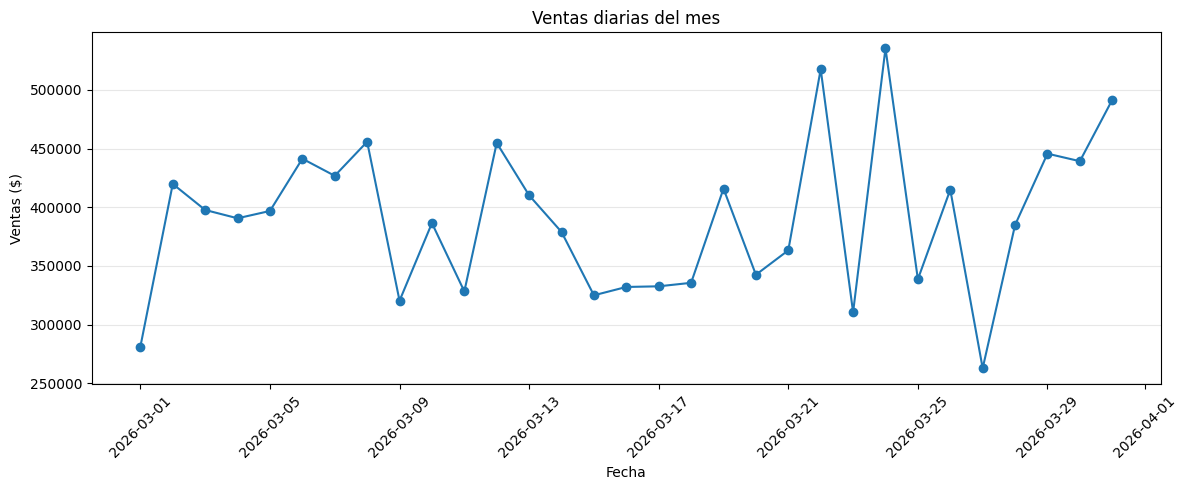

In [40]:
mejor_dia = ventas_diarias.loc[ventas_diarias["ventas"].idxmax()]
peor_dia = ventas_diarias.loc[ventas_diarias["ventas"].idxmin()]
print("Mejor día:", mejor_dia.to_dict())
print("Peor día:", peor_dia.to_dict())

plt.figure(figsize=(12,5))
plt.plot(ventas_diarias["fecha"],ventas_diarias["ventas"],marker="o")
plt.title("Ventas diarias del mes")
plt.xlabel("Fecha"); plt.ylabel("Ventas ($)")
plt.grid(axis="y",alpha=.3); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## Paso 6 · Base de conocimiento para RAG
RAG se usa para **definiciones y conocimiento textual**, no para sumar filas del CSV.

In [41]:
fecha_min, fecha_max = df["fecha"].min(), df["fecha"].max()
DOCUMENTOS_RAG = [
{"tema":"METRICAS","texto":"""[METRICAS]
Venta: importe final registrado después del descuento.
Unidades: cantidad de artículos vendidos.
Órdenes: número de id_orden únicos.
Clientes únicos: id_cliente diferentes.
Ticket promedio: ventas totales / número de órdenes.
Producto más vendido = más unidades. Producto con mayores ingresos = mayor venta."""},
{"tema":"DIMENSIONES","texto":"""[DIMENSIONES]
Las ventas pueden analizarse por producto, categoría, marca, región, canal, método de pago y fecha."""},
{"tema":"COLUMNAS","texto":"""[COLUMNAS]
id_orden: identificador de operación. fecha: día de venta. id_cliente: cliente. producto: artículo. categoria: grupo comercial. marca: marca. region: zona. canal: medio de compra. metodo_pago: forma de pago. unidades: artículos. precio_unitario: precio antes del descuento registrado. descuento_pct: porcentaje de descuento. venta: importe final."""},
{"tema":"SEMANAS","texto":"""[SEMANAS]
Semana 1: días 1-7. Semana 2: días 8-14. Semana 3: días 15-21. Semana 4: días 22-28. Semana 5: días 29-fin de mes."""},
{"tema":"ALCANCE","texto":f"""[ALCANCE]
El archivo cubre {fecha_min.date()} a {fecha_max.date()}. Puede calcular ventas, unidades, órdenes, clientes, ticket promedio, rankings y tendencias. No contiene vendedores, empleados, costos, utilidad, inventario, edad de clientes, tiempos de entrega ni satisfacción."""}
]
for d in DOCUMENTOS_RAG:
    print("\n---",d["tema"],"---\n",d["texto"])


--- METRICAS ---
 [METRICAS]
Venta: importe final registrado después del descuento.
Unidades: cantidad de artículos vendidos.
Órdenes: número de id_orden únicos.
Clientes únicos: id_cliente diferentes.
Ticket promedio: ventas totales / número de órdenes.
Producto más vendido = más unidades. Producto con mayores ingresos = mayor venta.

--- DIMENSIONES ---
 [DIMENSIONES]
Las ventas pueden analizarse por producto, categoría, marca, región, canal, método de pago y fecha.

--- COLUMNAS ---
 [COLUMNAS]
id_orden: identificador de operación. fecha: día de venta. id_cliente: cliente. producto: artículo. categoria: grupo comercial. marca: marca. region: zona. canal: medio de compra. metodo_pago: forma de pago. unidades: artículos. precio_unitario: precio antes del descuento registrado. descuento_pct: porcentaje de descuento. venta: importe final.

--- SEMANAS ---
 [SEMANAS]
Semana 1: días 1-7. Semana 2: días 8-14. Semana 3: días 15-21. Semana 4: días 22-28. Semana 5: días 29-fin de mes.

--- A

### Embeddings y recuperación semántica

In [42]:
from sentence_transformers import SentenceTransformer, util
modelo_embeddings = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
textos_rag = [d["texto"] for d in DOCUMENTOS_RAG]
embeddings_rag = modelo_embeddings.encode(textos_rag,convert_to_tensor=True)

def buscar_rag(pregunta,k=2):
    emb_q = modelo_embeddings.encode(pregunta,convert_to_tensor=True)
    hits = util.semantic_search(emb_q,embeddings_rag,top_k=k)[0]
    out=[]
    for h in hits:
        i=h["corpus_id"]
        out.append({"tema":DOCUMENTOS_RAG[i]["tema"],"texto":DOCUMENTOS_RAG[i]["texto"],"similitud":float(h["score"])})
    return out
print("RAG listo")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RAG listo


In [43]:
pruebas_rag=[
("¿Qué significa ticket promedio?","METRICAS"),
("¿Qué representa la columna venta?","COLUMNAS"),
("¿Qué puedo analizar por región o canal?","DIMENSIONES"),
("¿Qué días corresponden a la semana 2?","SEMANAS"),
("¿El archivo tiene información de vendedores?","ALCANCE")]
aciertos=0
for pregunta,esperado in pruebas_rag:
    top=buscar_rag(pregunta,k=1)[0]
    ok=top["tema"]==esperado; aciertos+=int(ok)
    print("✅" if ok else "❌",pregunta,"→",top["tema"],round(top["similitud"],4))
recall_1_rag=aciertos/len(pruebas_rag)
print("Recall@1:",f"{recall_1_rag:.1%}")

✅ ¿Qué significa ticket promedio? → METRICAS 0.4692
❌ ¿Qué representa la columna venta? → DIMENSIONES 0.5852
✅ ¿Qué puedo analizar por región o canal? → DIMENSIONES 0.4025
✅ ¿Qué días corresponden a la semana 2? → SEMANAS 0.7487
✅ ¿El archivo tiene información de vendedores? → ALCANCE 0.487
Recall@1: 80.0%


## Paso 7 · Dataset para Fine-Tuning
Clases: **ANALISIS** (Pandas), **RESUMEN**, **CONCEPTO** (RAG), **FUERA_ALCANCE**.

In [44]:
from datasets import Dataset
CLASES=["ANALISIS","RESUMEN","CONCEPTO","FUERA_ALCANCE"]
clase2id={c:i for i,c in enumerate(CLASES)}; id2clase={i:c for c,i in clase2id.items()}

MENSAJES_TRAIN=[
("¿Cuánto vendimos el 9 de marzo?","ANALISIS"),("¿Qué producto vendió más en la semana 2?","ANALISIS"),("¿Cuál fue la categoría con mayores ingresos?","ANALISIS"),("¿Qué región vendió menos?","ANALISIS"),("¿Se vendió más por Web o por App?","ANALISIS"),("¿Cuántas órdenes hubo el 20 de marzo?","ANALISIS"),("Dame los 5 productos con más unidades","ANALISIS"),("¿Qué día tuvo las ventas más altas?","ANALISIS"),("¿Cuántos clientes únicos compraron el 15 de marzo?","ANALISIS"),("¿Cuál fue el ticket promedio de la semana 1?","ANALISIS"),("Compara las ventas de Centro y Norte","ANALISIS"),("¿Cómo evolucionaron las ventas durante el mes?","ANALISIS"),
("Dame un resumen de las ventas del mes","RESUMEN"),("Quiero un panorama general de marzo","RESUMEN"),("Resume el desempeño comercial del mes","RESUMEN"),("Dame los principales indicadores del mes","RESUMEN"),("¿Cómo nos fue en términos generales?","RESUMEN"),("Hazme un resumen ejecutivo de las ventas","RESUMEN"),("Muéstrame los KPI principales","RESUMEN"),("Quiero ver el desempeño general","RESUMEN"),("Resume ventas, clientes y órdenes","RESUMEN"),("Dame el balance general de marzo","RESUMEN"),("¿Qué resultados generales tuvimos?","RESUMEN"),("Quiero una síntesis del mes","RESUMEN"),
("¿Qué significa ticket promedio?","CONCEPTO"),("¿Qué representa la columna venta?","CONCEPTO"),("¿Cómo se calcula el ticket promedio?","CONCEPTO"),("¿Qué significa clientes únicos?","CONCEPTO"),("¿Qué es una orden en esta base?","CONCEPTO"),("¿Qué columnas tiene el archivo?","CONCEPTO"),("¿Qué significa canal?","CONCEPTO"),("¿Cómo están definidas las semanas?","CONCEPTO"),("¿Qué días forman la semana 3?","CONCEPTO"),("¿Qué dimensiones se pueden analizar?","CONCEPTO"),("¿Qué significa descuento_pct?","CONCEPTO"),("¿Cuál es la diferencia entre unidades y ventas?","CONCEPTO"),
("¿Quién fue el vendedor del mes?","FUERA_ALCANCE"),("¿Cuál empleado vendió más?","FUERA_ALCANCE"),("¿Cuánta utilidad obtuvimos?","FUERA_ALCANCE"),("¿Cuál fue el costo total de los productos?","FUERA_ALCANCE"),("¿Cuánto inventario queda?","FUERA_ALCANCE"),("¿Qué edad tienen nuestros clientes?","FUERA_ALCANCE"),("¿Cuál fue el tiempo promedio de entrega?","FUERA_ALCANCE"),("¿Qué vendedor tuvo más comisiones?","FUERA_ALCANCE"),("¿Qué tan satisfechos quedaron los clientes?","FUERA_ALCANCE"),("¿Cuántos empleados participaron?","FUERA_ALCANCE"),("¿Cuál es la ganancia neta?","FUERA_ALCANCE"),("Pronostica las ventas del próximo año","FUERA_ALCANCE")]

PRUEBA_CLASIFICADOR=[
("¿Qué categoría vendió más el 12 de marzo?","ANALISIS"),("Dame el top 3 de productos de la segunda semana","ANALISIS"),("¿Cuál canal tuvo menos ventas?","ANALISIS"),("¿Cuánto vendimos en la última semana?","ANALISIS"),
("Dame un resumen ejecutivo del mes","RESUMEN"),("Quiero los indicadores generales de marzo","RESUMEN"),("Haz una síntesis de los resultados","RESUMEN"),("¿Cómo fue el desempeño general?","RESUMEN"),
("¿Qué quiere decir venta?","CONCEPTO"),("Explícame qué es una categoría","CONCEPTO"),("¿Cómo se divide la semana 2?","CONCEPTO"),("¿Qué significa método de pago?","CONCEPTO"),
("¿Qué vendedor fue el mejor?","FUERA_ALCANCE"),("¿Cuál fue nuestra utilidad?","FUERA_ALCANCE"),("¿Cuánto stock quedó al final?","FUERA_ALCANCE"),("¿Cuál fue la satisfacción promedio?","FUERA_ALCANCE")]

train_ds=Dataset.from_dict({"text":[t for t,c in MENSAJES_TRAIN],"labels":[clase2id[c] for t,c in MENSAJES_TRAIN]})
print(len(MENSAJES_TRAIN),"train ·",len(PRUEBA_CLASIFICADOR),"prueba")

48 train · 16 prueba


## Paso 8 · Clasificador ANTES del Fine-Tuning

In [45]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, logging
from sklearn.metrics import accuracy_score, f1_score, classification_report
logging.set_verbosity_error()
NOMBRE_MODELO="distilbert-base-multilingual-cased"
tokenizer=AutoTokenizer.from_pretrained(NOMBRE_MODELO)
modelo=AutoModelForSequenceClassification.from_pretrained(NOMBRE_MODELO,num_labels=len(CLASES),id2label=id2clase,label2id=clase2id)

def tokenizar(batch): return tokenizer(batch["text"],truncation=True,padding="max_length",max_length=80)
train_tok=train_ds.map(tokenizar,batched=True)

def clasificar(texto):
    inputs=tokenizer(texto,return_tensors="pt",truncation=True,max_length=80).to(modelo.device)
    modelo.eval()
    with torch.no_grad(): logits=modelo(**inputs).logits
    return id2clase[int(logits.argmax(dim=-1).item())]

def evaluar_clasificador():
    y_true=[c for _,c in PRUEBA_CLASIFICADOR]; y_pred=[clasificar(t) for t,_ in PRUEBA_CLASIFICADOR]
    return y_true,y_pred,accuracy_score(y_true,y_pred),f1_score(y_true,y_pred,average="macro")

antes_true,antes_pred,antes_acc,antes_f1=evaluar_clasificador()
print(f"Accuracy ANTES: {antes_acc:.2%}")
print(f"F1 macro ANTES: {antes_f1:.3f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Map:   0%|          | 0/48 [00:00<?, ? examples/s]

Accuracy ANTES: 31.25%
F1 macro ANTES: 0.194


## Paso 9 · Aplicar LoRA y entrenar

In [46]:
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer
config_lora=LoraConfig(task_type="SEQ_CLS",r=8,lora_alpha=16,target_modules=["q_lin","v_lin"],lora_dropout=.05,modules_to_save=["pre_classifier","classifier"])
modelo=get_peft_model(modelo,config_lora)
modelo.print_trainable_parameters()
args=TrainingArguments(output_dir="/content/analista_ventas_lora",num_train_epochs=20,per_device_train_batch_size=8,learning_rate=5e-4,logging_steps=5,save_strategy="no",report_to="none")
trainer=Trainer(model=modelo,args=args,train_dataset=train_tok)
trainer.train()
print("Fine-Tuning terminado")

trainable params: 741,124 || all params: 136,068,872 || trainable%: 0.5447


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.431', 'grad_norm': '2.449', 'learning_rate': '0.0004833', 'epoch': '0.8333'}
{'loss': '1.269', 'grad_norm': '1.933', 'learning_rate': '0.0004625', 'epoch': '1.667'}
{'loss': '1.298', 'grad_norm': '2.455', 'learning_rate': '0.0004417', 'epoch': '2.5'}
{'loss': '1.122', 'grad_norm': '2.036', 'learning_rate': '0.0004208', 'epoch': '3.333'}
{'loss': '1.001', 'grad_norm': '1.713', 'learning_rate': '0.0004', 'epoch': '4.167'}
{'loss': '0.9405', 'grad_norm': '2.228', 'learning_rate': '0.0003792', 'epoch': '5'}
{'loss': '0.7966', 'grad_norm': '2.275', 'learning_rate': '0.0003583', 'epoch': '5.833'}
{'loss': '0.7598', 'grad_norm': '3.436', 'learning_rate': '0.0003375', 'epoch': '6.667'}
{'loss': '0.6404', 'grad_norm': '2.517', 'learning_rate': '0.0003167', 'epoch': '7.5'}
{'loss': '0.4654', 'grad_norm': '3.084', 'learning_rate': '0.0002958', 'epoch': '8.333'}
{'loss': '0.3522', 'grad_norm': '2.003', 'learning_rate': '0.000275', 'epoch': '9.167'}
{'loss': '0.2169', 'grad_norm': '3.43

## Paso 10 · Evaluar DESPUÉS del Fine-Tuning

Accuracy ANTES   : 31.25%
Accuracy DESPUÉS : 93.75%
F1 ANTES         : 0.194
F1 DESPUÉS       : 0.937
✅ [ANALISIS] real=ANALISIS · ¿Qué categoría vendió más el 12 de marzo?
✅ [ANALISIS] real=ANALISIS · Dame el top 3 de productos de la segunda semana
✅ [ANALISIS] real=ANALISIS · ¿Cuál canal tuvo menos ventas?
✅ [ANALISIS] real=ANALISIS · ¿Cuánto vendimos en la última semana?
✅ [RESUMEN] real=RESUMEN · Dame un resumen ejecutivo del mes
✅ [RESUMEN] real=RESUMEN · Quiero los indicadores generales de marzo
✅ [RESUMEN] real=RESUMEN · Haz una síntesis de los resultados
❌ [FUERA_ALCANCE] real=RESUMEN · ¿Cómo fue el desempeño general?
✅ [CONCEPTO] real=CONCEPTO · ¿Qué quiere decir venta?
✅ [CONCEPTO] real=CONCEPTO · Explícame qué es una categoría
✅ [CONCEPTO] real=CONCEPTO · ¿Cómo se divide la semana 2?
✅ [CONCEPTO] real=CONCEPTO · ¿Qué significa método de pago?
✅ [FUERA_ALCANCE] real=FUERA_ALCANCE · ¿Qué vendedor fue el mejor?
✅ [FUERA_ALCANCE] real=FUERA_ALCANCE · ¿Cuál fue nuestra utilidad?


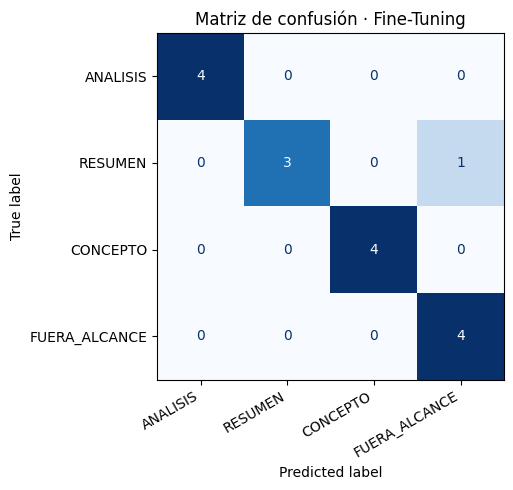

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

despues_true,despues_pred,despues_acc,despues_f1=evaluar_clasificador()
print(f"Accuracy ANTES   : {antes_acc:.2%}")
print(f"Accuracy DESPUÉS : {despues_acc:.2%}")
print(f"F1 ANTES         : {antes_f1:.3f}")
print(f"F1 DESPUÉS       : {despues_f1:.3f}")
for (texto,real),pred in zip(PRUEBA_CLASIFICADOR,despues_pred):
    print("✅" if pred==real else "❌",f"[{pred}] real={real} · {texto}")
print("\n",classification_report(despues_true,despues_pred,labels=CLASES,zero_division=0))
cm=confusion_matrix(despues_true,despues_pred,labels=CLASES)
fig,ax=plt.subplots(figsize=(6,5)); disp=ConfusionMatrixDisplay(cm,display_labels=CLASES); disp.plot(ax=ax,cmap="Blues",colorbar=False)
plt.title("Matriz de confusión · Fine-Tuning"); plt.xticks(rotation=30,ha="right"); plt.tight_layout()
RUTA_MATRIZ="/content/matriz_clasificador.png"; plt.savefig(RUTA_MATRIZ,dpi=140,bbox_inches="tight"); plt.show()

# Paso 11 · Motor de análisis dinámico con Pandas
Groq convierte la pregunta en un plan JSON; Pandas ejecuta el cálculo real.

In [48]:
def valores_validos():
    return {
        "productos":sorted(df["producto"].dropna().astype(str).unique().tolist()),
        "categorias":sorted(df["categoria"].dropna().astype(str).unique().tolist()),
        "regiones":sorted(df["region"].dropna().astype(str).unique().tolist()),
        "canales":sorted(df["canal"].dropna().astype(str).unique().tolist()),
        "metodos_pago":sorted(df["metodo_pago"].dropna().astype(str).unique().tolist())}
VALIDOS=valores_validos()

PROMPT_PLANIFICADOR="""
Eres un planificador de consultas para un CSV de ventas. Devuelve UN SOLO JSON válido y nada más.
PERIODO: {periodo}
Productos: {productos}
Categorías: {categorias}
Regiones: {regiones}
Canales: {canales}
Métodos de pago: {metodos_pago}

OPERACIONES: agregar, ranking, comparar, tendencia, resumen.
MÉTRICAS: venta, unidades, ordenes, clientes, ticket_promedio.
DIMENSIONES: null, producto, categoria, region, canal, metodo_pago, fecha.
REGLAS: 'más vendido'=unidades; 'mayores ventas/ingresos'=venta. Semana 1=1-7, 2=8-14, 3=15-21, 4=22-28, 5=29-fin. Para fecha concreta usa fecha_inicio=fecha_fin. ranking usa direccion mayor/menor. filtros solo producto/categoria/region/canal/metodo_pago.
FORMATO:
{
  "operacion":"agregar|ranking|comparar|tendencia|resumen",
  "metrica":"venta|unidades|ordenes|clientes|ticket_promedio",
  "dimension":null,
  "direccion":null,
  "top_n":1,
  "fecha_inicio":null,
  "fecha_fin":null,
  "semana":null,
  "filtros":{},
  "valores":[]
}
PREGUNTA: {pregunta}
"""

def extraer_json(texto):
    ini,fin=texto.find("{"),texto.rfind("}")
    if ini<0 or fin<0: raise ValueError("Groq no devolvió JSON.")
    return json.loads(texto[ini:fin+1])

def planificar_consulta(pregunta):
    p=PROMPT_PLANIFICADOR
    p=p.replace("{periodo}",f"{df['fecha'].min().date()} a {df['fecha'].max().date()}")
    p=p.replace("{productos}",", ".join(VALIDOS["productos"]))
    p=p.replace("{categorias}",", ".join(VALIDOS["categorias"]))
    p=p.replace("{regiones}",", ".join(VALIDOS["regiones"]))
    p=p.replace("{canales}",", ".join(VALIDOS["canales"]))
    p=p.replace("{metodos_pago}",", ".join(VALIDOS["metodos_pago"]))
    p=p.replace("{pregunta}",pregunta)
    return extraer_json(preguntar_groq(p,0.0))
print("Planificador listo")

Planificador listo


In [49]:
def rango_semana(n):
    n=int(n); inicio_mes=df["fecha"].min().normalize(); fin_mes=df["fecha"].max().normalize(); di=1+(n-1)*7
    if di>fin_mes.day: return None,None
    dfinal=min(di+6,fin_mes.day); return inicio_mes.replace(day=di),inicio_mes.replace(day=dfinal)

def filtrar_base(plan):
    base=df.copy()
    if plan.get("semana") is not None:
        ini,fin=rango_semana(plan["semana"])
        if ini is None: return base.iloc[0:0]
        base=base[(base["fecha"]>=ini)&(base["fecha"]<=fin)]
    if plan.get("fecha_inicio"): base=base[base["fecha"]>=pd.to_datetime(plan["fecha_inicio"])]
    if plan.get("fecha_fin"): base=base[base["fecha"]<=pd.to_datetime(plan["fecha_fin"])]
    for campo,valor in (plan.get("filtros") or {}).items():
        if campo in ["producto","categoria","region","canal","metodo_pago"]:
            base=base[base[campo].astype(str).str.casefold()==str(valor).casefold()]
    return base

def calcular_metrica(base,m):
    if m=="venta": return round(float(base["venta"].sum()),2)
    if m=="unidades": return int(base["unidades"].sum())
    if m=="ordenes": return int(base["id_orden"].nunique())
    if m=="clientes": return int(base["id_cliente"].nunique())
    if m=="ticket_promedio":
        n=base["id_orden"].nunique(); return round(float(base["venta"].sum()/n),2) if n else 0
    raise ValueError(m)

def agrupar_metrica(base,dim,m):
    if m=="venta": return base.groupby(dim)["venta"].sum()
    if m=="unidades": return base.groupby(dim)["unidades"].sum()
    if m=="ordenes": return base.groupby(dim)["id_orden"].nunique()
    if m=="clientes": return base.groupby(dim)["id_cliente"].nunique()
    if m=="ticket_promedio": return base.groupby(dim).apply(lambda x:x["venta"].sum()/x["id_orden"].nunique() if x["id_orden"].nunique() else 0)
    raise ValueError(m)

def ejecutar_plan(plan):
    base=filtrar_base(plan)
    if base.empty: return {"status":"sin_datos","mensaje":"No hay registros con esos filtros."}
    op=plan.get("operacion"); m=plan.get("metrica","venta"); dim=plan.get("dimension")
    if op=="resumen": return {"status":"ok","tipo":"resumen","resultado":resumen_mes(base)}
    if op=="agregar": return {"status":"ok","tipo":"agregado","metrica":m,"resultado":calcular_metrica(base,m),"registros_considerados":len(base)}
    if op in ("ranking","comparar"):
        if dim is None: return {"status":"error","mensaje":"Falta dimensión."}
        s=agrupar_metrica(base,dim,m)
        vals=plan.get("valores") or []
        if op=="comparar" and vals:
            mapa={str(i).casefold():i for i in s.index}; idx=[mapa[str(v).casefold()] for v in vals if str(v).casefold() in mapa]; s=s.loc[idx]
        s=s.sort_values(ascending=(plan.get("direccion")=="menor")); s=s.head(int(plan.get("top_n") or 10))
        out=[]
        for i,v in s.items():
            if isinstance(i,pd.Timestamp): i=i.strftime("%Y-%m-%d")
            out.append({dim:str(i),m:round(float(v),2)})
        return {"status":"ok","tipo":op,"dimension":dim,"metrica":m,"resultado":out}
    if op=="tendencia":
        s=agrupar_metrica(base,"fecha",m).sort_index(); out=[{"fecha":i.strftime("%Y-%m-%d"),m:round(float(v),2)} for i,v in s.items()]
        return {"status":"ok","tipo":"tendencia","metrica":m,"resultado":out}
    return {"status":"error","mensaje":f"Operación no soportada: {op}"}

print("Motor Pandas listo")

Motor Pandas listo


### Probar consultas dinámicas

In [50]:
preguntas_dinamicas=["¿Cuánto vendimos el 9 de marzo?","¿Qué producto fue el más vendido en la semana 2?","¿Qué región tuvo mayores ventas?","Compara las ventas de Web y App","¿Cuál fue el día con menores ventas?"]
for q in preguntas_dinamicas:
    plan=planificar_consulta(q); r=ejecutar_plan(plan)
    print("\n"+"="*80); print("PREGUNTA:",q); print("PLAN:",json.dumps(plan,ensure_ascii=False,indent=2)); print("RESULTADO:",json.dumps(r,ensure_ascii=False,indent=2,default=str))


PREGUNTA: ¿Cuánto vendimos el 9 de marzo?
PLAN: {
  "operacion": "agregar",
  "metrica": "venta",
  "dimension": null,
  "direccion": null,
  "top_n": 1,
  "fecha_inicio": "2026-03-09",
  "fecha_fin": "2026-03-09",
  "semana": null,
  "filtros": {},
  "valores": []
}
RESULTADO: {
  "status": "ok",
  "tipo": "agregado",
  "metrica": "venta",
  "resultado": 320263.65,
  "registros_considerados": 93
}

PREGUNTA: ¿Qué producto fue el más vendido en la semana 2?
PLAN: {
  "operacion": "ranking",
  "metrica": "unidades",
  "dimension": "producto",
  "direccion": "mayor",
  "top_n": 1,
  "fecha_inicio": null,
  "fecha_fin": null,
  "semana": 2,
  "filtros": {},
  "valores": [
    "Smartphone X1"
  ]
}
RESULTADO: {
  "status": "ok",
  "tipo": "ranking",
  "dimension": "producto",
  "metrica": "unidades",
  "resultado": [
    {
      "producto": "Audífonos AirBeat",
      "unidades": 72.0
    }
  ]
}

PREGUNTA: ¿Qué región tuvo mayores ventas?
PLAN: {
  "operacion": "ranking",
  "metrica": "ve

##Paso 12 · Prompt Engineering y pipeline completo

In [51]:
PROMPT_RESPUESTA_DATOS="""Eres un analista de ventas. Responde usando ÚNICAMENTE el RESULTADO CALCULADO con Pandas. No inventes. Si hay error o sin_datos, dilo. Sé breve y profesional. Formato monetario $1,234,567.89.
PREGUNTA:
{pregunta}
RESULTADO:
{resultado}"""
PROMPT_RESPUESTA_RAG="""Eres un analista de datos. Responde usando ÚNICAMENTE el CONTEXTO. No inventes. Sé breve.
PREGUNTA:
{pregunta}
CONTEXTO:
{contexto}"""
PROMPT_RESUMEN="""Redacta un resumen ejecutivo breve usando ÚNICAMENTE estos KPI. Incluye ventas totales, unidades, órdenes, clientes únicos y ticket promedio.
KPI:
{kpis}"""

def responder_datos(pregunta,resultado):
    p=PROMPT_RESPUESTA_DATOS.replace("{pregunta}",pregunta).replace("{resultado}",json.dumps(resultado,ensure_ascii=False,indent=2,default=str)); return preguntar_groq(p,.2)

def responder_con_rag(pregunta,k=2):
    rec=buscar_rag(pregunta,k); ctx="\n\n".join(x["texto"] for x in rec); p=PROMPT_RESPUESTA_RAG.replace("{pregunta}",pregunta).replace("{contexto}",ctx); return preguntar_groq(p,.2),rec

def responder_resumen():
    datos=resumen_mes(df); p=PROMPT_RESUMEN.replace("{kpis}",json.dumps(datos,ensure_ascii=False,indent=2)); return preguntar_groq(p,.2),datos

def atender_consulta(pregunta):
    clase=clasificar(pregunta)
    if clase=="ANALISIS":
        plan=planificar_consulta(pregunta); ev=ejecutar_plan(plan); return {"clase":clase,"respuesta":responder_datos(pregunta,ev),"plan":plan,"evidencia":ev,"contexto":None}
    if clase=="RESUMEN":
        resp,ev=responder_resumen(); return {"clase":clase,"respuesta":resp,"plan":{"operacion":"resumen"},"evidencia":ev,"contexto":None}
    if clase=="CONCEPTO":
        resp,ctx=responder_con_rag(pregunta); return {"clase":clase,"respuesta":resp,"plan":None,"evidencia":None,"contexto":ctx}
    return {"clase":"FUERA_ALCANCE","respuesta":"La información solicitada no está disponible en las columnas del archivo de ventas de este proyecto.","plan":None,"evidencia":None,"contexto":None}
print("Pipeline completo listo")

Pipeline completo listo


In [52]:
PRUEBAS_PIPELINE=["¿Cuánto vendimos el 9 de marzo?","¿Qué producto fue el más vendido en la semana 2?","Dame un resumen ejecutivo del mes","¿Qué significa ticket promedio?","¿Cuál vendedor fue el más destacado?"]
resultados_pipeline=[]
for q in PRUEBAS_PIPELINE:
    r=atender_consulta(q); resultados_pipeline.append({"pregunta":q,**r})
    print("\n"+"="*90); print("PREGUNTA:",q); print("RUTA:",r["clase"]); print("RESPUESTA:",r["respuesta"])


PREGUNTA: ¿Cuánto vendimos el 9 de marzo?
RUTA: ANALISIS
RESPUESTA: $320,263.65

PREGUNTA: ¿Qué producto fue el más vendido en la semana 2?
RUTA: ANALISIS
RESPUESTA: ```json
{
  "status": "ok",
  "tipo": "ranking",
  "dimension": "producto",
  "metrica": "unidades",
  "resultado": [
    {
      "producto": "Audífonos AirBeat",
      "unidades": 72.0
    }
  ]
}
```

PREGUNTA: Dame un resumen ejecutivo del mes
RUTA: RESUMEN
RESPUESTA: **Resumen Ejecutivo**

Durante el periodo analizado, la empresa alcanzó **ventas totales de 12 075 836 €**, distribuidas en **3 000 órdenes** que generaron un total de **4 054 unidades**. El negocio atendió a **908 clientes únicos**, lo que refleja una base de clientes sólida y diversificada. El **ticket promedio** se situó en **4 025,28 €**, indicando un alto valor medio por transacción y una buena capacidad de conversión de ventas. En conjunto, estos indicadores demuestran un rendimiento financiero robusto y una operación eficiente en términos de volume

##Paso 13 · Juez de calidad con Groq
Evaluación complementaria de fidelidad y claridad.

In [53]:
PROMPT_JUEZ="""Eres un juez de calidad. Evalúa RESPUESTA contra EVIDENCIA. Devuelve SOLO JSON válido: {"exactitud":1,"claridad":1,"invento_informacion":false,"comentario":"frase breve"}. Usa escala 1-5.
PREGUNTA:{pregunta}
EVIDENCIA:{evidencia}
RESPUESTA:{respuesta}"""

def evidencia_para_juez(item):
    if item["clase"]=="CONCEPTO": return "\n\n".join(x["texto"] for x in (item.get("contexto") or []))
    if item["clase"]=="FUERA_ALCANCE": return "La información solicitada no existe en el CSV."
    return json.dumps(item.get("evidencia"),ensure_ascii=False,default=str)

def juzgar_item(item):
    p=PROMPT_JUEZ.replace("{pregunta}",item["pregunta"]).replace("{evidencia}",evidencia_para_juez(item)).replace("{respuesta}",item["respuesta"]); return extraer_json(preguntar_groq(p,0.0))

evaluacion_juez=[]
for item in resultados_pipeline:
    v=juzgar_item(item); evaluacion_juez.append({"pregunta":item["pregunta"],**v}); print("\n",item["pregunta"],"→",v)
notas=[x["exactitud"] for x in evaluacion_juez if isinstance(x.get("exactitud"),(int,float))]
promedio_exactitud=round(sum(notas)/len(notas),2) if notas else None
print("\nExactitud promedio del juez:",promedio_exactitud,"/ 5")


 ¿Cuánto vendimos el 9 de marzo? → {'exactitud': 5, 'claridad': 5, 'invento_informacion': False, 'comentario': 'Respuesta correcta'}

 ¿Qué producto fue el más vendido en la semana 2? → {'exactitud': 5, 'claridad': 5, 'invento_informacion': False, 'comentario': 'Respuesta correcta'}

 Dame un resumen ejecutivo del mes → {'exactitud': 5, 'claridad': 5, 'invento_informacion': False, 'comentario': 'Respuesta precisa y clara'}

 ¿Qué significa ticket promedio? → {'exactitud': 5, 'claridad': 5, 'invento_informacion': False, 'comentario': 'Respuesta correcta y clara'}

 ¿Cuál vendedor fue el más destacado? → {'exactitud': 5, 'claridad': 5, 'invento_informacion': False, 'comentario': 'Respuesta correcta y clara'}

Exactitud promedio del juez: 5.0 / 5


##Paso 14 · App Gradio

In [55]:
import os, gradio as gr

def ui_consultar(pregunta):
    if not pregunta or not pregunta.strip(): return "—","Escribe una consulta.",{}
    try:
        r=atender_consulta(pregunta); detalle={"ruta":r["clase"],"plan":r.get("plan"),"evidencia":r.get("evidencia"),"contexto_rag":r.get("contexto")}; return r["clase"],r["respuesta"],detalle
    except Exception as e:
        return "ERROR",f"Ocurrió un error: {type(e).__name__}",{"detalle":str(e)}

resumen_metricas=f"""### 📊 Evaluación
- Accuracy antes: {antes_acc:.2%}
- Accuracy después: {despues_acc:.2%}
- F1 después: {despues_f1:.3f}
- RAG Recall@1: {recall_1_rag:.1%}
- Juez LLM: {promedio_exactitud} / 5"""
EJEMPLOS_UI=["¿Cuánto vendimos el 9 de marzo?","¿Qué producto fue el más vendido en la semana 2?","¿Qué región tuvo mayores ventas?","Dame un resumen ejecutivo del mes","¿Qué significa ticket promedio?","¿Cuál vendedor fue el más destacado?"]
with gr.Blocks(title="Analista IA de Ventas") as demo:

    gr.Markdown("""
# 📊 Analista IA de Ventas Mensuales

Consulta el archivo de ventas utilizando **Fine-Tuning, Pandas, RAG y un LLM**.

El asistente puede responder distintos tipos de preguntas.
""")

    with gr.Tabs():

        with gr.Tab("💬 Consultar"):

            pregunta = gr.Textbox(
                label="Pregunta",
                placeholder="Ejemplo: ¿Cuánto vendimos el 9 de marzo?",
                lines=2,
            )

            boton = gr.Button(
                "Analizar",
                variant="primary"
            )

            ruta = gr.Textbox(
                label="Ruta detectada",
                interactive=False
            )

            respuesta = gr.Markdown()

            with gr.Accordion(
                "🔍 Ver cómo se resolvió",
                open=False
            ):
                detalle = gr.JSON(
                    label="Plan / evidencia / contexto"
                )

            # =====================================================
            # EJEMPLOS POR TIPO DE PREGUNTA
            # =====================================================

            gr.Markdown("## 💡 Ejemplos de consultas")

            gr.Markdown("""
### 📊 Análisis
Preguntas que requieren calcular información directamente sobre el CSV.
""")

            gr.Examples(
                examples=[
                    ["¿Cuánto vendimos el 9 de marzo?"],
                    ["¿Qué producto fue el más vendido en la semana 2?"],
                    ["¿Qué región tuvo mayores ventas?"],
                    ["¿Cuál fue el día con menores ventas?"],
                    ["Compara las ventas de Web y App"],
                ],
                inputs=pregunta
            )

            gr.Markdown("""
### 📋 Resumen
Preguntas que solicitan una visión general del desempeño del mes.
""")

            gr.Examples(
                examples=[
                    ["Dame un resumen ejecutivo del mes"],
                    ["¿Cuáles fueron los principales indicadores de marzo?"],
                    ["¿Cómo fue el desempeño general del mes?"],
                ],
                inputs=pregunta
            )

            gr.Markdown("""
### 📚 Conceptos
Preguntas sobre el significado de métricas, columnas o estructura de los datos.
""")

            gr.Examples(
                examples=[
                    ["¿Qué significa ticket promedio?"],
                    ["¿Qué representa la columna venta?"],
                    ["¿Qué significa clientes únicos?"],
                    ["¿Cómo se define la semana 2?"],
                ],
                inputs=pregunta
            )

            gr.Markdown("""
### 🚫 Fuera de alcance
Preguntas cuya información no existe en el archivo de ventas.
""")

            gr.Examples(
                examples=[
                    ["¿Cuál vendedor fue el más destacado?"],
                    ["¿Cuánta utilidad obtuvimos?"],
                    ["¿Cuánto inventario quedó?"],
                ],
                inputs=pregunta
            )

            boton.click(
                ui_consultar,
                inputs=pregunta,
                outputs=[
                    ruta,
                    respuesta,
                    detalle
                ]
            )

        with gr.Tab("📈 Evaluación"):

            gr.Markdown(resumen_metricas)

            if os.path.exists(RUTA_MATRIZ):
                gr.Image(
                    value=RUTA_MATRIZ,
                    label="Matriz de confusión"
                )

demo.launch(
    share=True,
    debug=False
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7267ebcbfee5b23eec.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusiones y límites

- **Fine-Tuning + LoRA:** decide qué ruta usar.
- **Pandas:** calcula resultados exactos y dinámicos.
- **Embeddings + RAG:** recupera definiciones y conocimiento textual.
- **Prompt Engineering:** controla interpretación y generación.
- **Groq:** estructura planes y redacta respuestas.
- **Evaluación:** compara antes/después y verifica RAG y fidelidad.
- **Gradio:** integra el prototipo.

### Limitaciones
Trabaja con un solo mes y con las columnas conocidas. No calcula vendedores, costos, utilidad, inventario ni otras variables que no existan en el CSV.